In [3]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 3.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.0 MB 7.1 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 9.5 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.0 MB 7.9 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 5.5 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 4.9 MB/s eta 0:00:01
   ---------------------------------- ----- 6.8/8.0 MB 4.6 MB/s eta 0:00:01
   -------------------------------------- - 7.6/8.0 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 4.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 25.1 MB/s eta 0:00:02
    --------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Required Libraries

This cell imports all libraries required for KNN, preprocessing, and evaluation metrics.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Load the Dataset

Load your CSV dataset and display the first 5 rows to confirm it's loaded correctly.

In [43]:
df = pd.read_csv("students_dataset.csv", on_bad_lines='skip')
df.head()

,student_id,age,gender,study_hours,extracurricular,sleep_hours,previous_score,attendance_rate,favorite_subject,parental_support,internet_access,target_grade
0,1,17,Male,18.324,Yes,7.842,82.456,91.234,Math,High,Yes,A
1,2,16,Female,15.678,No,6.123,71.890,88.567,Science,Medium,Yes,B
2,3,18,Male,21.456,Yes,8.901,89.123,93.456,Math,High,Yes,A
3,4,19,Female,12.345,Yes,5.678,64.789,76.890,English,Low,No,C
4,5,17,Male,17.890,No,7.234,77.012,85.678,History,Medium,Yes,B


In [44]:
df.shape

(199, 12)

In [45]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours', 'extracurricular',
       'sleep_hours', 'previous_score', 'attendance_rate', 'favorite_subject',
       'parental_support', 'internet_access', 'target_grade'],
      dtype='object')

In [46]:
df.dtypes

student_id            int64
age                   int64
gender               object
study_hours         float64
extracurricular      object
sleep_hours         float64
previous_score      float64
attendance_rate     float64
favorite_subject     object
parental_support     object
internet_access      object
target_grade         object
dtype: object

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        199 non-null    int64  
 1   age               199 non-null    int64  
 2   gender            199 non-null    object 
 3   study_hours       199 non-null    float64
 4   extracurricular   199 non-null    object 
 5   sleep_hours       199 non-null    float64
 6   previous_score    199 non-null    float64
 7   attendance_rate   199 non-null    float64
 8   favorite_subject  199 non-null    object 
 9   parental_support  199 non-null    object 
 10  internet_access   199 non-null    object 
 11  target_grade      199 non-null    object 
dtypes: float64(4), int64(2), object(6)
memory usage: 18.8+ KB


In [48]:
df.isnull().sum()

student_id          0
age                 0
gender              0
study_hours         0
extracurricular     0
sleep_hours         0
previous_score      0
attendance_rate     0
favorite_subject    0
parental_support    0
internet_access     0
target_grade        0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(99)

In [50]:
[df['age'] > 100]

[0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 194    False
 195    False
 196    False
 197    False
 198    False
 Name: age, Length: 199, dtype: bool]

In [51]:
df[df['age'] >= 100]

,student_id,age,gender,study_hours,extracurricular,sleep_hours,previous_score,attendance_rate,favorite_subject,parental_support,internet_access,target_grade
51,52,120,Male,25.123,Yes,10.234,150.0,99.999,Math,High,Yes,A
150,52,120,Male,25.123,Yes,10.234,150.0,99.999,Math,High,Yes,A


In [52]:
df[df['study_hours'] < 0]

,student_id,age,gender,study_hours,extracurricular,sleep_hours,previous_score,attendance_rate,favorite_subject,parental_support,internet_access,target_grade
52,53,16,Female,-5.0,No,6.456,45.678,60.123,Art,Low,No,F
151,53,16,Female,-5.0,No,6.456,45.678,60.123,Art,Low,No,F


In [53]:
df[df['previous_score'] > 100]

,student_id,age,gender,study_hours,extracurricular,sleep_hours,previous_score,attendance_rate,favorite_subject,parental_support,internet_access,target_grade
51,52,120,Male,25.123,Yes,10.234,150.0,99.999,Math,High,Yes,A
150,52,120,Male,25.123,Yes,10.234,150.0,99.999,Math,High,Yes,A


##  Basic Cleaning

- Fill missing numeric values with mean.
- Fill missing categorical values with mode.
- Remove unrealistic outliers (age > 100, negative study hours, previous_score > 100).

In [54]:
# numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
# df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# categorical_cols = df.select_dtypes(include=['object']).columns
# df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

df = df[df['age'] < 100]
df = df[df['study_hours'] >= 0]
df = df[df['previous_score'] <= 100]

df.shape

(195, 12)

## Encode Categorical Columns

Convert categorical features into numbers using LabelEncoder.

In [55]:
le = LabelEncoder()
for col in ['gender', 'extracurricular', 'favorite_subject', 'target_grade', 'parental_support', 'internet_access']:
    df[col] = le.fit_transform(df[col])

In [56]:
df.head()

,student_id,age,gender,study_hours,extracurricular,sleep_hours,previous_score,attendance_rate,favorite_subject,parental_support,internet_access,target_grade
0,1,17,1,18.324,1,7.842,82.456,91.234,3,0,1,0
1,2,16,0,15.678,0,6.123,71.890,88.567,4,2,1,1
2,3,18,1,21.456,1,8.901,89.123,93.456,3,0,1,0
3,4,19,0,12.345,1,5.678,64.789,76.890,1,1,0,2
4,5,17,1,17.890,0,7.234,77.012,85.678,2,2,1,1


## Select Features (X) and Target (y)

`X` contains all input features, `y` is the target grade.

In [57]:
X = df.drop('target_grade', axis=1)
y = df['target_grade']

In [58]:
X

,student_id,age,gender,study_hours,extracurricular,sleep_hours,previous_score,attendance_rate,favorite_subject,parental_support,internet_access
0,1,17,1,18.324,1,7.842,82.456,91.234,3,0,1
1,2,16,0,15.678,0,6.123,71.890,88.567,4,2,1
2,3,18,1,21.456,1,8.901,89.123,93.456,3,0,1
3,4,19,0,12.345,1,5.678,64.789,76.890,1,1,0
4,5,17,1,17.890,0,7.234,77.012,85.678,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...
194,96,17,1,15.890,0,6.789,70.456,80.456,1,2,1
195,97,18,0,20.456,1,8.456,88.123,93.123,3,0,1
196,98,19,1,13.234,1,5.567,64.890,75.678,2,1,1
197,99,16,0,17.901,0,7.456,75.678,83.901,4,2,1


In [59]:
y

0      0
1      1
2      0
3      2
4      1
      ..
194    1
195    0
196    2
197    1
198    0
Name: target_grade, Length: 195, dtype: int64

## Train/Test Split

Split dataset into training and testing sets (80% train, 20% test).

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)
print("Training Data:", y_train.shape)
print("Testing Data:", y_test.shape)

Training Data: (156, 11)
Testing Data: (39, 11)
Training Data: (156,)
Testing Data: (39,)


## Feature Scaling

KNN uses distances, so features must be scaled to avoid bias.

In [61]:
X_train.dtypes

student_id            int64
age                   int64
gender                int64
study_hours         float64
extracurricular       int64
sleep_hours         float64
previous_score      float64
attendance_rate     float64
favorite_subject      int64
parental_support      int64
internet_access       int64
dtype: object

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
X_train_scaled

array([[-1.52946043,  0.18854629, -0.96225045, ...,  1.14048726,
        -1.2040288 ,  0.4778561 ],
       [-0.39509041,  1.00558022,  1.03923048, ...,  1.14048726,
         1.18869085,  0.4778561 ],
       [-0.84196345, -0.62848764, -0.96225045, ...,  0.42596512,
         1.18869085, -2.09268018],
       ...,
       [ 1.52990114,  1.82261414, -0.96225045, ...,  1.14048726,
        -1.2040288 ,  0.4778561 ],
       [ 1.18615265,  1.82261414, -0.96225045, ..., -0.28855702,
        -0.00766897, -2.09268018],
       [-1.52946043,  0.18854629, -0.96225045, ...,  1.14048726,
        -1.2040288 ,  0.4778561 ]], shape=(156, 11))

## Train KNN Model

Train KNN classifier with K=5.

In [64]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Make Predictions

Predict target grades for test data.

In [65]:
y_pred = knn.predict(X_test_scaled)
y_pred[:10]

array([4, 0, 1, 1, 2, 2, 0, 1, 1, 1])

## Accuracy

Percentage of correctly predicted values.

In [66]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8717948717948718


## Precision, Recall, F1 Score

- Precision: Correct positive predictions
- Recall: How many real positives captured
- F1 Score: Balance between precision and recall

In [71]:
#print(" Precision Formula: TP / (TP + FP)")
#print(" Recall Formula: TP / (TP + FN)")
#print(" F1 Score Formula: 2 * (Precision * Recall) / (Precision + Recall)")

![](https://accessibleai.dev/img/Metrics/Classification/ConfusionAll.png)

In [67]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8692307692307691
Recall: 0.8717948717948718
F1 Score: 0.8632478632478632


## Confusion Matrix

Shows correct vs misclassified predictions.

In [68]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[15,  0,  0,  0,  0],
       [ 0, 14,  1,  0,  0],
       [ 0,  0,  3,  1,  0],
       [ 0,  1,  1,  1,  1],
       [ 0,  0,  0,  0,  1]])

In [76]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

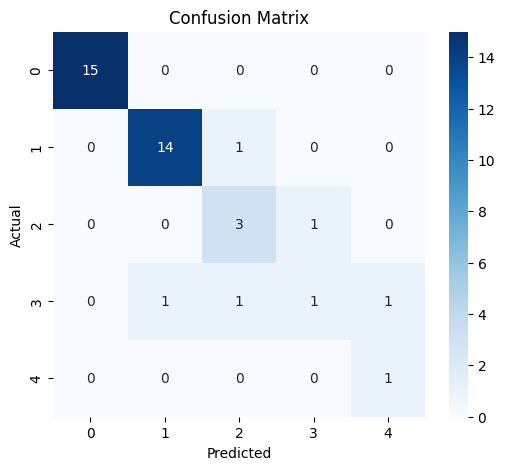

In [78]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Classification Report

Detailed metrics per class (Precision, Recall, F1, Support).

In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.60      0.75      0.67         4
           3       0.50      0.25      0.33         4
           4       0.50      1.00      0.67         1

    accuracy                           0.87        39
   macro avg       0.71      0.79      0.72        39
weighted avg       0.87      0.87      0.86        39

